# NYC: current vs conservative charging (non-learning)

1000 vehicles, 500 HEVs + 500 AEVs, 3 AEV centers × 50 slots; 10 paired seeds per scenario; 4-hour horizon. **Controlled charging demand, not passenger-service evaluation.** Each vehicle requests one charge. AEV assignment prioritizes the number admitted, then travel time, using the same OR-Tools adapter in both arms. HEV station choices and all initial conditions are paired.

Two scenarios: **Burst** (all requests released at time zero) and **Staggered** (releases spread over the first two hours). Each starts with 30 charging AEVs and 15 committed inbound AEVs. These are included in the 500 AEVs, not extra vehicles. No neural network or learning penalty is used.

All results below come from the actual NYC movement/action/update loop. No calendar-only replay or release-order repair is substituted. Change `FLEET` to inspect the HEV control or all vehicles.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src" / "NYCEnvironment.py").exists():
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / "results" / "nyc_charging_rollout_1000"
FLEET = "AEV"  # AEV, HEV, ALL
FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
manifest = json.loads((RESULTS_DIR / "manifest.json").read_text())
raw = pd.DataFrame(json.loads((RESULTS_DIR / "summary.json").read_text()))
scenarios = manifest["config"]["scenarios"]
seeds = manifest["config"]["seeds"]
policies = ["current", "conservative"]
labels = {"current": "Current", "conservative": "Conservative"}
scenario_labels = {"burst": "Burst", "staggered": "Staggered"}
colors = {"current": "#EF4054", "conservative": "#299F93"}
df = raw.loc[raw.fleet.eq(FLEET)].copy()
expected = {(s, k, p) for s in scenarios for k in seeds for p in policies}
actual = set(df[["scenario", "seed", "policy"]].itertuples(index=False, name=None))
assert actual == expected, f"Incomplete experiment: missing {expected - actual}"
assert not df.duplicated(["scenario", "seed", "policy"]).any()
assert df.groupby(["scenario", "seed"]).initial_state_sha256.nunique().eq(1).all()
plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
                     "axes.titleweight": "bold", "figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"Fleet: {FLEET}; {len(df)} runs; {len(seeds)} paired seeds per scenario")
display(pd.DataFrame([manifest["config"]]))

Fleet: AEV; 40 runs; 10 paired seeds per scenario


,vehicles,hev,centers,hours,seeds,scenarios,output_dir
0,1000,500,3,4.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[burst, staggered]",/Users/seinzhou/Desktop/icaps/results/nyc_char...


### Metric definitions

- **Occupancy/utilization:** occupied physical plugs sampled after actions, before charging progress/releases, averaged over the common 4-hour horizon. AEV utilization uses 150 slots; HEV uses the public network. Empty slots after work completes remain in the denominator.
- **Arrival wait:** accumulated queue exposure at 30-second resolution, including a queue entered and cleared within the same simulator epoch. The main mean includes zero-wait arrivals and excludes vehicles already charging at time zero. End-of-run unfinished queues contribute their observed wait so far (a censored lower bound).
- **Queue length:** total vehicles queued across the selected fleet's stations, sampled at the same phase. Individual AEV station rows are also saved.
- **Completions:** physically completed sessions within the horizon, including the initial charging vehicles. One session per vehicle.
- **Dispatch delay:** time from request release until assignment; unresolved requests use delay observed up to the horizon. This prevents interpreting station-side zero wait as zero total delay.
- **Native wait:** the environment's raw `start_epoch - arrival_epoch` is separately retained. It can be zero even when arrival was blocked until the release phase of that epoch. `ever_queued` is therefore the safety test.

Bars show equal-seed means with 95% Student-t confidence intervals (n=10). These are short-horizon scenario results, not a general no-queue proof.

mean_occupied_slots  utilization  \
scenario  policy                                           
burst     conservative              135.907        0.906   
          current                   134.126        0.894   
staggered conservative              130.277        0.869   
          current                   131.045        0.874   

                        mean_wait_minutes_all_arrivals  \
scenario  policy                                         
burst     conservative                           1.383   
          current                               71.538   
staggered conservative                           0.936   
          current                                3.988   

                        mean_wait_minutes_queued_arrivals  mean_queue_length  \
scenario  policy                                                               
burst     conservative                              2.137              2.441   
          current                                 100.109            126.302   
staggered conservative                              1.799              1.652   
          current                                   6.174              7.042   

                        max_queue_length  completion_count  \
scenario  policy                                             
burst     conservative              18.7             412.0   
          current                  273.8             409.7   
staggered conservative              11.0             361.0   
          current                   26.4             359.1   

                        queued_arrival_count  newly_assigned_queued_count  \
scenario  policy                                                            
burst     conservative                 274.2                        274.0   
          current                      302.7                        289.1   
staggered conservative                 219.7                        219.7   
          current                      273.6                        273.0   

                        dispatch_delay_lower_bound_minutes  \
scenario  policy                                             
burst     conservative                              81.298   
          current                                   22.272   
staggered conservative                              43.816   
          current                                   38.931   

                        pending_dispatch_count  pending_inbound_count  \
scenario  policy                                                        
burst     conservative                    46.4                    0.0   
          current                         46.4                    0.0   
staggered conservative                    46.4                    0.0   
          current                         46.4                    0.0   

                        pending_queue_count  pending_charging_count  
scenario  policy                                                     
burst     conservative                  0.0                    41.6  
          current                       0.0                    43.9  
staggered conservative                  0.0                    92.6  
          current                       0.0                    94.5

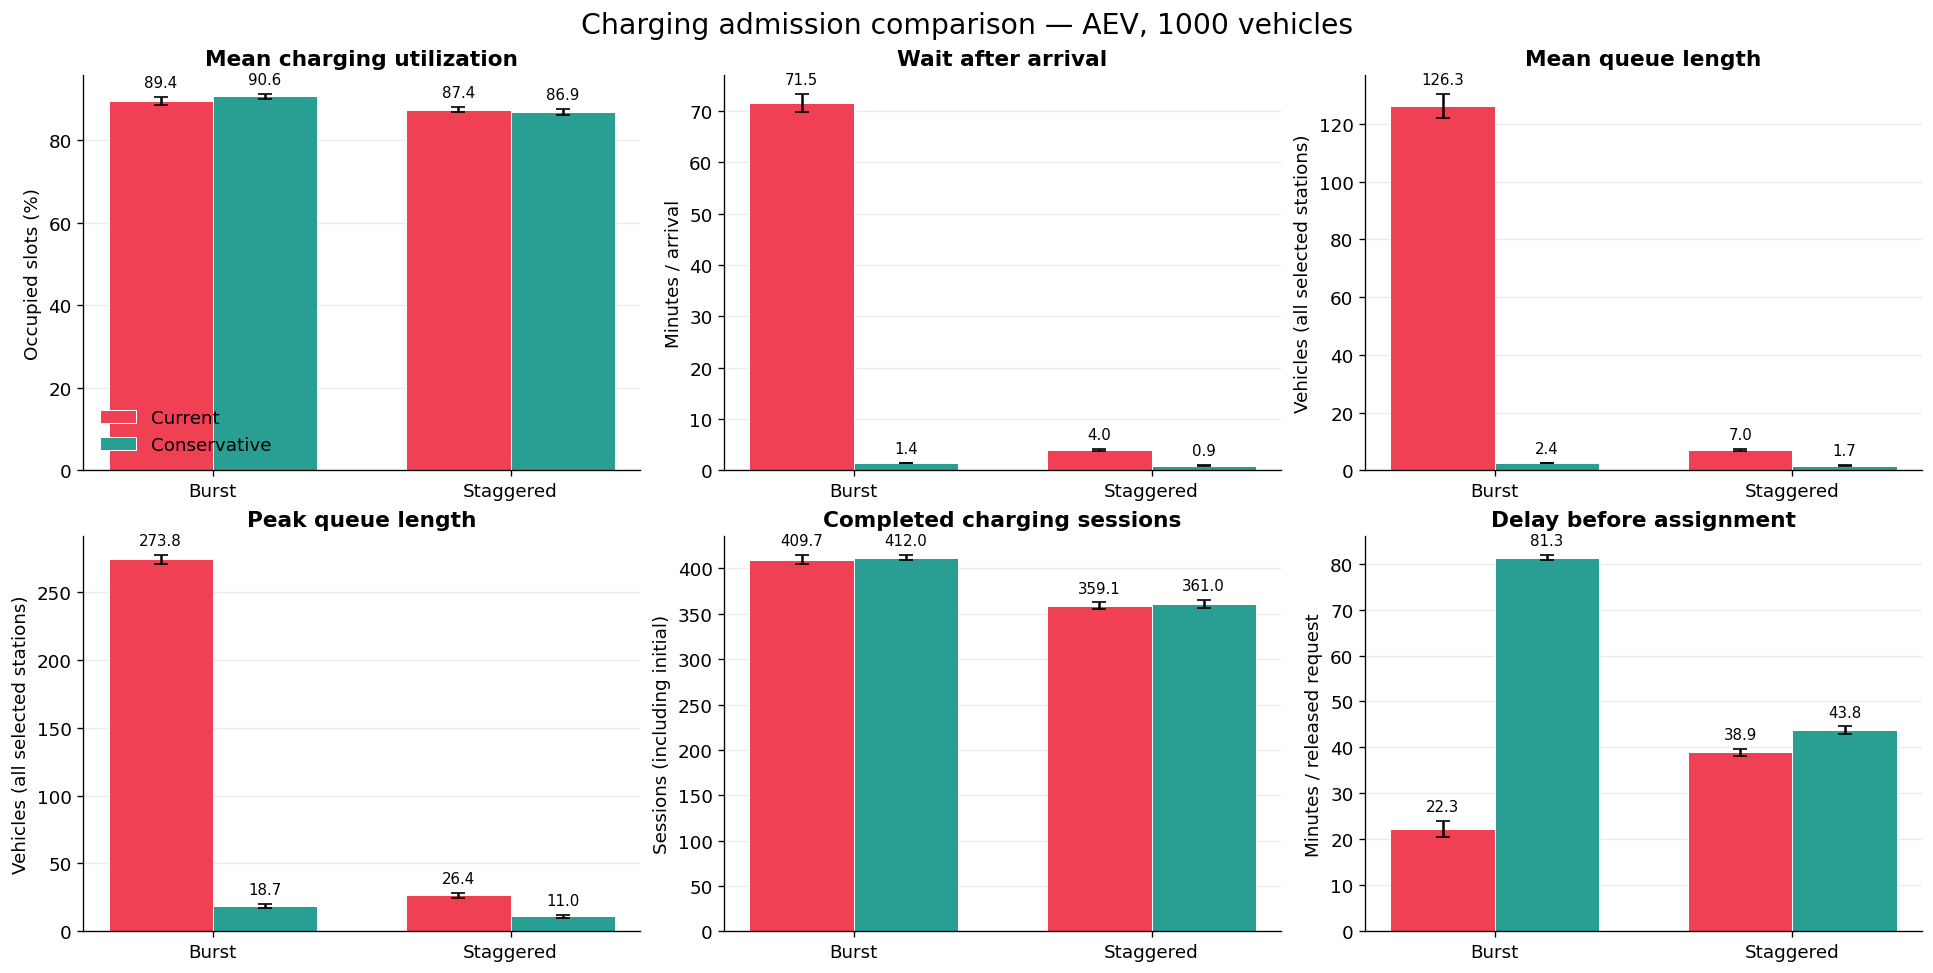

In [2]:
metrics = ["mean_occupied_slots", "utilization", "mean_wait_minutes_all_arrivals", "mean_wait_minutes_queued_arrivals",
           "mean_queue_length", "max_queue_length", "completion_count",
           "queued_arrival_count", "newly_assigned_queued_count",
           "dispatch_delay_lower_bound_minutes", "pending_dispatch_count",
           "pending_inbound_count", "pending_queue_count", "pending_charging_count"]
summary = df.groupby(["scenario", "policy"])[metrics].agg(["mean", "std", "count"])
display(summary.xs("mean", axis=1, level=1).round(3))
summary.xs("mean", axis=1, level=1).reset_index().to_json(
    RESULTS_DIR / f"analysis_means_{FLEET}.json", orient="records", indent=2)

def mean_ci(values):
    a = pd.Series(values).dropna().to_numpy(dtype=float)
    return (float(a.mean()), float(t.ppf(.975, len(a)-1) * a.std(ddof=1)/np.sqrt(len(a)))) if len(a)>1 else (float(a.mean()), 0.)

panels = [("utilization", "Mean charging utilization", "Occupied slots (%)", 100),
          ("mean_wait_minutes_all_arrivals", "Wait after arrival", "Minutes / arrival", 1),
          ("mean_queue_length", "Mean queue length", "Vehicles (all selected stations)", 1),
          ("max_queue_length", "Peak queue length", "Vehicles (all selected stations)", 1),
          ("completion_count", "Completed charging sessions", "Sessions (including initial)", 1),
          ("dispatch_delay_lower_bound_minutes", "Delay before assignment", "Minutes / released request", 1)]
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
x = np.arange(len(scenarios)); width = .35
for ax, (metric, title, ylabel, scale) in zip(axes.flat, panels):
    for i, policy in enumerate(policies):
        stats = [mean_ci(df.loc[df.scenario.eq(s) & df.policy.eq(policy), metric] * scale) for s in scenarios]
        y, err = np.array(stats).T
        bars = ax.bar(x + (i-.5)*width, y, width, yerr=err, capsize=4,
                      color=colors[policy], label=labels[policy], edgecolor="white", linewidth=.6)
        ax.bar_label(bars, labels=[f"{v:.1f}" for v in y], padding=4, fontsize=9)
    ax.set(title=title, ylabel=ylabel, xticks=x, xticklabels=[scenario_labels[s] for s in scenarios])
    ax.set_ylim(bottom=0); ax.margins(y=.18); ax.grid(axis="y", alpha=.25); ax.set_axisbelow(True)
axes[0, 0].legend(frameon=False)
fig.suptitle(f"Charging admission comparison — {FLEET}, {manifest['config']['vehicles']} vehicles", fontsize=17)
fig.savefig(FIGURE_DIR / f"comparison_{FLEET}.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / f"comparison_{FLEET}.pdf", bbox_inches="tight")
plt.show()

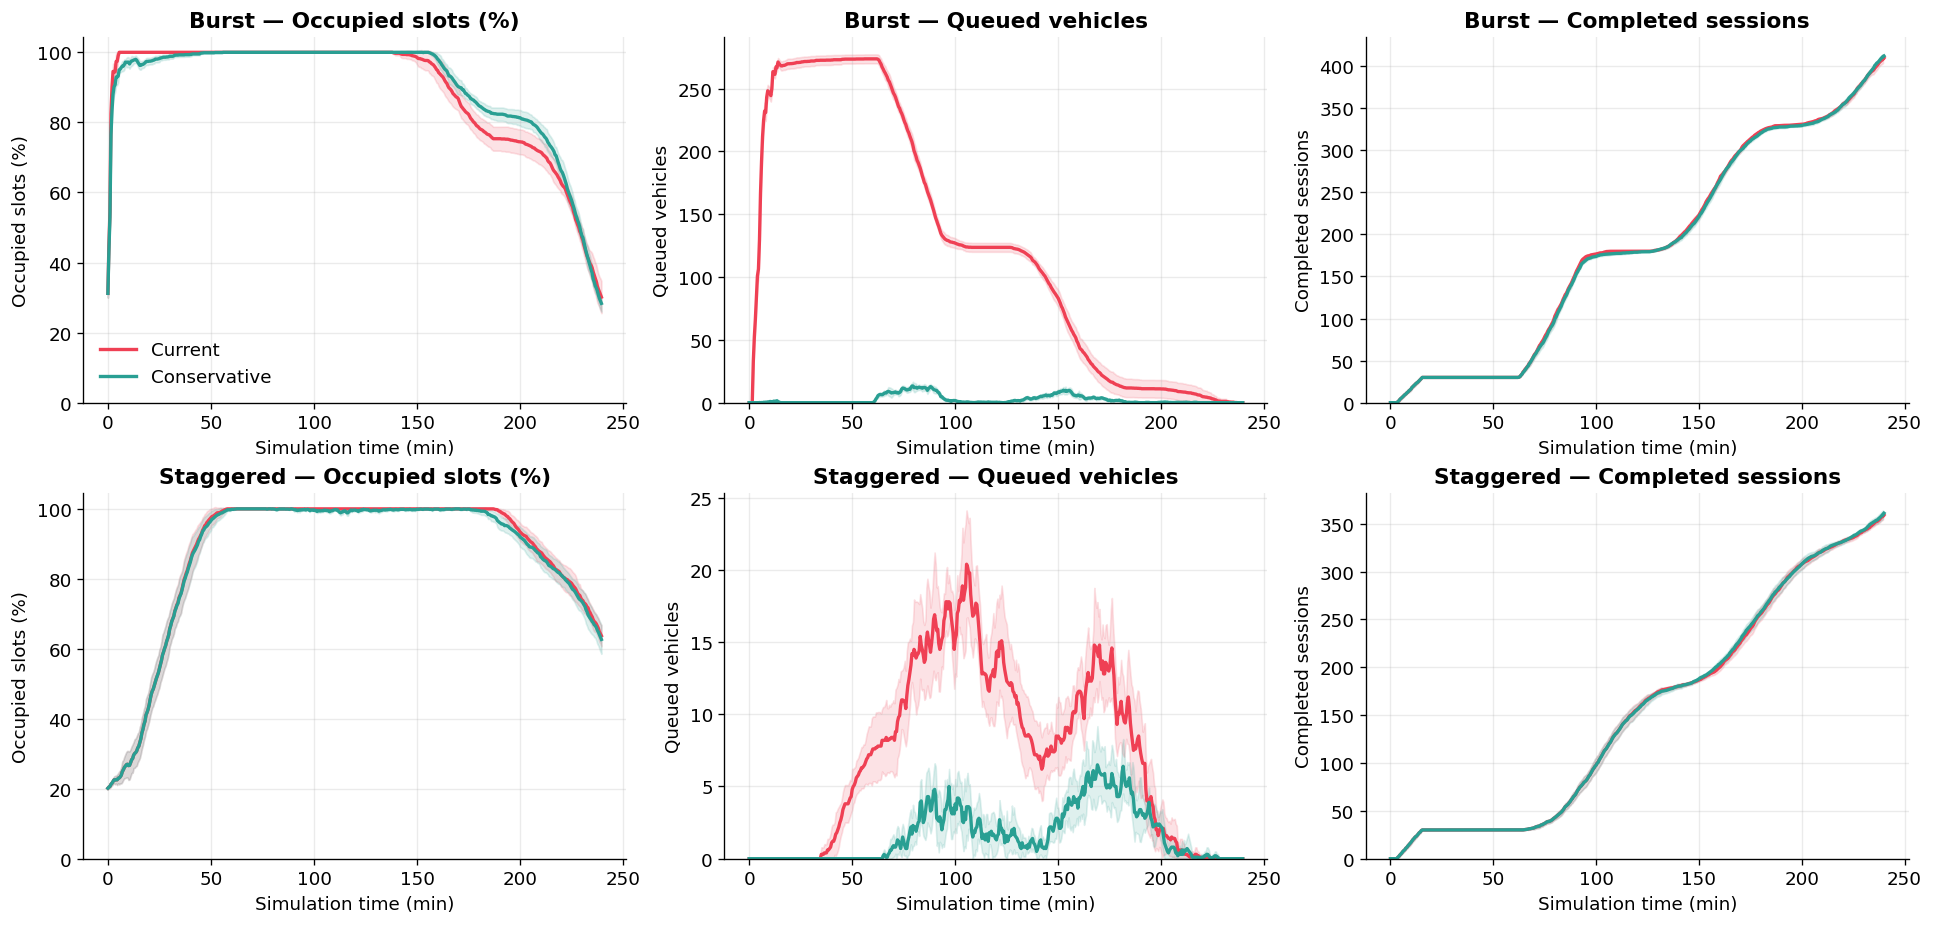

In [3]:
series, session_frames, event_frames, admission_frames = [], [], [], []
for scenario in scenarios:
    for seed in seeds:
        for policy in policies:
            folder = RESULTS_DIR / f"{scenario}_seed{seed}_{policy}"
            for name, sink in [("timeseries", series), ("sessions", session_frames),
                               ("events", event_frames), ("admissions", admission_frames)]:
                path = folder / f"{name}.jsonl"
                records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
                frame = pd.DataFrame(records)
                if not frame.empty:
                    frame = frame.assign(scenario=scenario, seed=seed, policy=policy)
                    sink.append(frame)
ts = pd.concat(series, ignore_index=True)
sessions = pd.concat(session_frames, ignore_index=True)
events = pd.concat(event_frames, ignore_index=True)
admissions = pd.concat(admission_frames, ignore_index=True)
ts = ts.loc[ts.fleet.eq(FLEET)].copy()
ts["utilization_percent"] = 100 * ts.occupied / ts.capacity
fig, axes = plt.subplots(len(scenarios), 3, figsize=(16, 3.8*len(scenarios)), squeeze=False, constrained_layout=True)
for row, scenario in enumerate(scenarios):
    for col, (metric, ylabel) in enumerate([("utilization_percent", "Occupied slots (%)"),
                                          ("queue", "Queued vehicles"), ("completed", "Completed sessions")]):
        ax = axes[row, col]
        for policy in policies:
            data = ts.loc[ts.scenario.eq(scenario) & ts.policy.eq(policy)]
            curve = data.groupby("minutes")[metric].agg(["mean", "std", "count"])
            ci = t.ppf(.975, curve["count"]-1) * curve["std"] / np.sqrt(curve["count"])
            ax.plot(curve.index, curve["mean"], color=colors[policy], label=labels[policy], lw=2)
            ax.fill_between(curve.index, np.maximum(0, curve["mean"]-ci), curve["mean"]+ci,
                            color=colors[policy], alpha=.15)
            if metric == "completed":
                endpoint = df.loc[df.scenario.eq(scenario) & df.policy.eq(policy), "completion_count"].mean()
                ax.plot([curve.index[-1], manifest["config"]["hours"]*60], [curve["mean"].iloc[-1], endpoint], color=colors[policy], lw=2)
        ax.set(title=f"{scenario_labels[scenario]} — {ylabel}", xlabel="Simulation time (min)", ylabel=ylabel)
        ax.set_ylim(bottom=0); ax.grid(alpha=.25)
axes[0,0].legend(frameon=False)
fig.savefig(FIGURE_DIR / f"timeseries_{FLEET}.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / f"timeseries_{FLEET}.pdf", bbox_inches="tight")
plt.show()

### Validate conservative arrivals, including transient queues

The statement “no assigned AEV ever queues on arrival” passes only if **every newly assigned conservative AEV** has `ever_queued=False`. Committed inbound vehicles are also shown separately. A positive queue entry counts as a violation even if the native timestamp difference is zero. Zero observed violations in finite runs is empirical evidence, not an unconditional MDP guarantee.

In [4]:
aev = raw.loc[raw.fleet.eq("AEV")].copy()
validation = aev.groupby(["scenario", "policy"]).agg(
    runs=("seed", "size"), total_arrivals=("arrival_count", "sum"),
    queued_arrivals=("queued_arrival_count", "sum"),
    newly_assigned_queued=("newly_assigned_queued_count", "sum"),
    committed_queued=("initial_committed_queued_count", "sum"),
    same_epoch_queue_then_start=("same_epoch_queue_then_start_count", "sum"),
    runs_with_any_queue=("no_arrival_queue_observed", lambda x: int((~x).sum())))
display(validation)
validation.reset_index().to_json(RESULTS_DIR / "validation.json", orient="records", indent=2)
violations = sessions.loc[sessions.fleet.eq("AEV") & sessions.policy.eq("conservative") & sessions.ever_queued].copy()
violations = violations.merge(admissions, how="left", on=["scenario", "seed", "policy", "vehicle_id", "station_id"], suffixes=("", "_admission"))
violations["arrival_error_epochs"] = violations.arrival_epoch - violations.expected_arrival
columns = ["scenario", "seed", "vehicle_id", "station_id", "initial_committed", "assignment_epoch",
           "expected_arrival", "arrival_epoch", "start_epoch", "queued_steps", "arrival_error_epochs"]
print(f"Conservative AEVs with a physical queue entry: {len(violations)}")
print("Observed no-arrival-queue condition:", "PASS (finite sample only)" if violations.empty else "FAIL")
display(violations[columns].head(20))
violations[columns].to_json(RESULTS_DIR / "conservative_queue_violations.json", orient="records", indent=2)

# HEV control must match: its exogenous choices and public network are paired.
hev = raw.loc[raw.fleet.eq("HEV")].pivot(index=["scenario", "seed"], columns="policy", values=["completion_count", "mean_queue_length", "utilization"])
for metric in ["completion_count", "mean_queue_length", "utilization"]:
    np.testing.assert_allclose(hev[metric]["current"], hev[metric]["conservative"], atol=1e-12)
print("Paired HEV control: identical for all seeds.")

runs  total_arrivals  queued_arrivals  \
scenario  policy                                                
burst     conservative    10            4236             2742   
          current         10            4236             3027   
staggered conservative    10            4236             2197   
          current         10            4236             2736   

                        newly_assigned_queued  committed_queued  \
scenario  policy                                                  
burst     conservative                   2740                 2   
          current                        2891               136   
staggered conservative                   2197                 0   
          current                        2730                 6   

                        same_epoch_queue_then_start  runs_with_any_queue  
scenario  policy                                                          
burst     conservative                            0                   10  
          current                                 0                   10  
staggered conservative                            0                   10  
          current                                 0                   10

Conservative AEVs with a physical queue entry: 4939
Observed no-arrival-queue condition: FAIL


,scenario,seed,vehicle_id,station_id,initial_committed,assignment_epoch,expected_arrival,arrival_epoch,start_epoch,queued_steps,arrival_error_epochs
0,burst,0,545,9000002.0,False,172.0,183.0,179.0,183.0,4,-4.0
1,burst,0,548,9000001.0,False,310.0,338.0,333.0,335.0,2,-5.0
2,burst,0,551,9000004.0,False,167.0,187.0,181.0,186.0,5,-6.0
3,burst,0,552,9000004.0,False,263.0,285.0,280.0,285.0,5,-5.0
4,burst,0,553,9000002.0,False,162.0,172.0,167.0,171.0,4,-5.0
5,burst,0,554,9000002.0,False,150.0,159.0,155.0,159.0,4,-4.0
6,burst,0,555,9000002.0,False,152.0,161.0,157.0,161.0,4,-4.0
7,burst,0,556,9000004.0,False,138.0,154.0,148.0,153.0,5,-6.0
8,burst,0,557,9000002.0,False,152.0,161.0,156.0,161.0,5,-5.0
9,burst,0,558,9000002.0,False,292.0,305.0,300.0,305.0,5,-5.0


Paired HEV control: identical for all seeds.


### Inspect a single seed / station

Raw station series retain occupancy, physical queue length and committed inbound counts for each AEV center. Admissions retain the forecast used when dispatching; session/event files retain actual arrivals, queue entries, starts and completions. Use these to investigate a violation rather than assuming a zero native wait means no blockage.

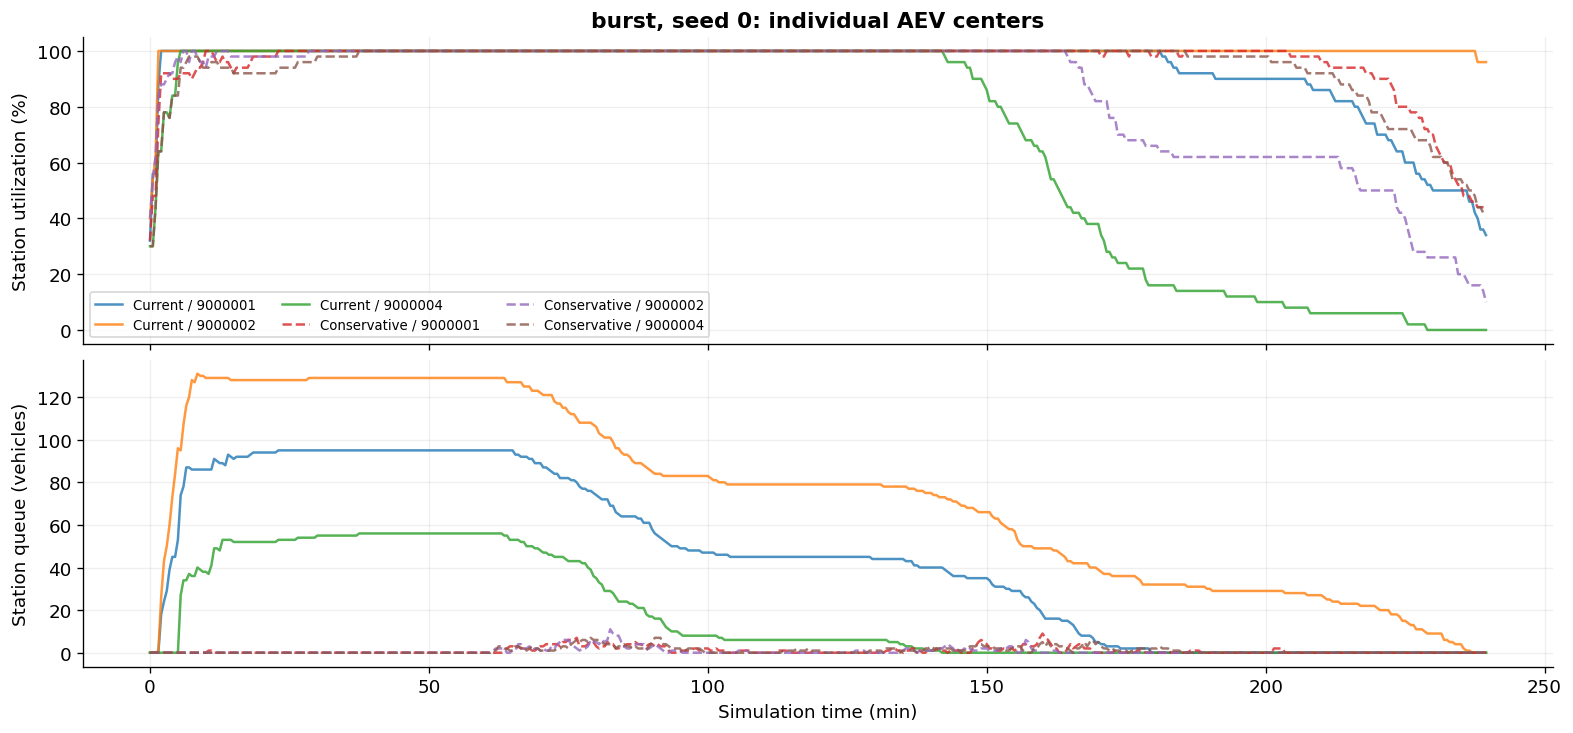

In [5]:
SCENARIO, SEED = scenarios[0], seeds[0]
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
for policy in policies:
    folder = RESULTS_DIR / f"{SCENARIO}_seed{SEED}_{policy}"
    station = pd.read_json(folder / "stations.jsonl", lines=True)
    for sid, data in station.groupby("station_id"):
        axes[0].plot(data.epoch*.5, data.occupied/data.capacity*100, label=f"{labels[policy]} / {sid}",
                     linestyle="-" if policy=="current" else "--", alpha=.8)
        axes[1].plot(data.epoch*.5, data.queue, linestyle="-" if policy=="current" else "--", alpha=.8)
axes[0].set(ylabel="Station utilization (%)", title=f"{SCENARIO}, seed {SEED}: individual AEV centers")
axes[1].set(ylabel="Station queue (vehicles)", xlabel="Simulation time (min)")
axes[0].legend(ncol=3, fontsize=8)
for ax in axes: ax.grid(alpha=.2)
fig.savefig(FIGURE_DIR / f"station_detail_{SCENARIO}_seed{SEED}.png", dpi=300, bbox_inches="tight")
plt.show()

### Arrival-time mismatch: conservative does not yet eliminate queues

Every conservative seed in both scenarios contains newly assigned AEVs that queue after arrival. The following audit compares the forecast saved **at assignment** with actual arrival, rather than treating an updated forecast as the original promise.

In this dataset all 4,937 newly assigned conservative queue cases arrived 2–6 epochs (1–3 minutes) before their forecast; the median is 4 epochs (2 minutes). The code forecasts travel between zone centroids (`calculate_expected_entercharge_station_time_battery`), while physical charging arrival is triggered as soon as the vehicle maps to the station zone (`_execute_movement_towards_charging_station`). This timing mismatch is visible in the recorded counterexamples. Thus a capacity check at the forecast arrival is insufficient to certify no waiting under current execution semantics.

Example: burst, seed 0, vehicle 545 was assigned at epoch 172 with forecast arrival 183, actually arrived at 179, and started charging at 183: 2 minutes of queue exposure. This experiment preserves the production simulator and reports the violation; it does not repair execution semantics or claim a no-queue guarantee.

Conservative substantially reduces station-side waiting here, but also delays dispatch. Occupancy and throughput are similar under this repeated, charge-only admission workload. These results do not establish the same behavior under passenger demand or learned dispatch.

In [6]:
violations = pd.DataFrame(json.loads((RESULTS_DIR / "conservative_queue_violations.json").read_text()))
new_violations = violations.loc[~violations.initial_committed].copy()
arrival_audit = new_violations.groupby("scenario").arrival_error_epochs.agg(["count", "min", "median", "max"])
arrival_audit["early_arrivals"] = new_violations.groupby("scenario").arrival_error_epochs.apply(lambda s: int(s.lt(0).sum()))
display(arrival_audit)
arrival_audit.reset_index().to_json(RESULTS_DIR / "arrival_prediction_audit.json", orient="records", indent=2)
display(new_violations.loc[new_violations.scenario.eq("burst") & new_violations.seed.eq(0) & new_violations.vehicle_id.eq(545)])

,count,min,median,max,early_arrivals
scenario,,,,,
burst,2740,-6.0,-4.0,-2.0,2740
staggered,2197,-6.0,-4.0,-2.0,2197


,scenario,seed,vehicle_id,station_id,initial_committed,assignment_epoch,expected_arrival,arrival_epoch,start_epoch,queued_steps,arrival_error_epochs
0,burst,0,545,9000002.0,False,172.0,183.0,179.0,183.0,4,-4.0
